# 실습 2. 다중 선형 회귀

## 데이터
- `data/boston_housing_train.csv`
- 입력 feature: `RM`, `LSTAT`, `PTRATIO`, `DIS`, `NOX`
- target: `MEDV`

## 불러온 데이터와 컬럼 정보

### Boston Housing 데이터
- 파일 경로: `data/boston_housing_train.csv`
- 데이터 크기: 506행, 14컬럼
- 데이터 내용: 지역별 주택 가격과 주변 환경 정보를 담은 회귀 예제 데이터
- target 컬럼: `MEDV`

| 컬럼 | 의미 | 이번 실습 사용 |
|---|---|---|
| `CRIM` | 지역별 1인당 범죄율 |  |
| `ZN` | 25,000 제곱피트 초과 주거지역 비율 |  |
| `INDUS` | 비소매 상업지역 비율 |  |
| `CHAS` | 찰스강 인접 여부. 인접하면 1, 아니면 0 |  |
| `NOX` | 일산화질소 농도 | 사용 feature |
| `RM` | 주택 1가구당 평균 방 개수 | 사용 feature |
| `AGE` | 1940년 이전 건축된 자가주택 비율 |  |
| `DIS` | 주요 고용 중심지까지의 가중 거리 | 사용 feature |
| `RAD` | 방사형 고속도로 접근성 지수 |  |
| `TAX` | 재산세율 |  |
| `PTRATIO` | 학생/교사 비율 | 사용 feature |
| `B` | 인구 통계 기반 지표. 수업에서는 해석하지 않음 |  |
| `LSTAT` | 저소득층 인구 비율 | 사용 feature |
| `MEDV` | 주택 가격 중앙값. 단위는 1,000달러 | target |


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

housing_df = pd.read_csv('data/boston_housing_train.csv')

feature_names = ['RM', 'LSTAT', 'PTRATIO', 'DIS', 'NOX']
target_name = 'MEDV'

practice_df = housing_df[feature_names + [target_name]].dropna().copy()
X = practice_df[feature_names]
y = practice_df[target_name]

print(practice_df.shape)
practice_df.head()


(506, 6)


,RM,LSTAT,PTRATIO,DIS,NOX,MEDV
0,6.575,4.98,15.3,4.0900,0.538,24.0
1,6.421,9.14,17.8,4.9671,0.469,21.6
2,7.185,4.03,17.8,4.9671,0.469,34.7
3,6.998,2.94,18.7,6.0622,0.458,33.4
4,7.147,5.33,18.7,6.0622,0.458,36.2


## 문제 1. 데이터 분리와 스케일링

다중 선형 회귀에 사용할 데이터를 학습/평가용으로 분리하고, `StandardScaler`로 feature를 스케일링하세요.

### 요구사항
- `test_size=0.2`, `random_state=42` 사용
- 스케일러 변수명은 `scaler`
- 훈련 데이터에는 `fit_transform()` 사용
- 평가 데이터에는 `transform()` 사용

### 힌트
- 스케일링 기준은 반드시 훈련 데이터에서만 학습함.

### 실행 결과

```text
X_train_scaled: (404, 5)
X_test_scaled: (102, 5)
```


In [14]:
# TODO: train_test_split()으로 학습/평가 데이터를 분리하세요.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: StandardScaler를 생성하세요.
scaler = StandardScaler()


# TODO: 훈련 데이터에는 fit_transform(), 평가 데이터에는 transform()을 적용하세요.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# TODO: 변환된 데이터 shape를 출력하세요.
print(f'X_train_scared  shape: {X_train_scaled .shape}')
print(f'X_test_scared  shape: {X_test_scaled .shape}')

X_train_scared  shape: (404, 5)
X_test_scared  shape: (102, 5)


## 문제 2. 다중 선형 회귀 모델 학습

`LinearRegression` 모델을 생성하고 스케일링된 훈련 데이터로 학습하세요.

### 요구사항
- 모델 변수명은 `multi_lin_reg`
- 학습 후 feature별 회귀계수를 DataFrame으로 정리

### 힌트
- `coef_`의 순서는 `feature_names`의 순서와 같음.

### 실행 결과

```text
절편: 22.796534653465343
```

```text
feature      coef
0       RM  3.219924
4      NOX -2.113137
2  PTRATIO -2.214225
3      DIS -2.603842
1    LSTAT -4.127738
```


In [15]:
# TODO: LinearRegression 모델을 생성하세요.
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

# TODO: 스케일링된 훈련 데이터로 모델을 학습하세요.
regressor.fit(X_train_scaled, y_train)

# TODO: feature별 회귀계수를 DataFrame으로 정리하세요.
regressor_coef = pd.DataFrame(regressor.coef_)

regressor_coef

,0
0,3.219924
1,-4.127738
2,-2.214225
3,-2.603842
4,-2.113137


## 문제 3. 모델 평가와 예측

평가 데이터에서 예측값을 만들고 회귀 평가지표를 계산하세요.

### 요구사항
- `R2`, `MAE`, `RMSE` 출력
- 평가 데이터 앞 5개의 실제값과 예측값을 비교하는 DataFrame 생성

### 힌트
- 예측값과 실제값을 나란히 보면 오차의 크기를 직관적으로 볼 수 있음.

### 실행 결과

```text
R2: 0.6563982005228932
MAE: 3.2721352283630996
RMSE: 5.019723085624437
```

```text
actual       pred     error
0    23.6  29.203910 -5.603910
1    32.4  32.347515  0.052485
2    13.6  17.678467 -4.078467
3    22.8  25.581471 -2.781471
4    16.1  16.989702 -0.889702
```


In [16]:
# TODO: 평가 데이터 예측값 y_pred를 생성하세요.
y_pred = regressor.predict(X_test_scaled)

# TODO: R2, MAE, RMSE를 출력하세요.
print(f'R2 : {r2_score(y_test, y_pred)}')
print(f'MAE : {mean_absolute_error(y_test, y_pred)}')
print(f'RMSE : {root_mean_squared_error(y_test, y_pred)}')

# TODO: 실제값, 예측값, 오차를 비교하는 DataFrame을 생성하세요.
results = pd.DataFrame

real = y_test.copy()
pred = regressor.predict(X_test_scaled)
diff = real - pred

results = pd.DataFrame({
    'real': real,
    'pred': pred,
    'diff': diff
})

print(results)

R2 : 0.656398200522893
MAE : 3.2721352283630996
RMSE : 5.019723085624438
     real       pred       diff
173  23.6  29.203910  -5.603910
274  32.4  32.347515   0.052485
491  13.6  17.678467  -4.078467
72   22.8  25.581471  -2.781471
452  16.1  16.989702  -0.889702
..    ...        ...        ...
412  17.9   2.547352  15.352648
436   9.6  17.243487  -7.643487
411  17.2  19.443243  -2.243243
86   22.5  22.189285   0.310715
75   21.4  25.623764  -4.223764

[102 rows x 3 columns]


## 문제 4. 회귀계수 시각화

feature별 회귀계수를 막대그래프로 시각화하세요.

### 요구사항
- x축: feature 이름
- y축: 회귀계수
- 기준선 `y=0` 표시

### 힌트
- 양수 계수는 target을 올리는 방향, 음수 계수는 target을 낮추는 방향으로 해석할 수 있음.

### 실행 결과

![정답 실행 그래프](images/02_multiple_linear_regression_problem_4_fig1.png)


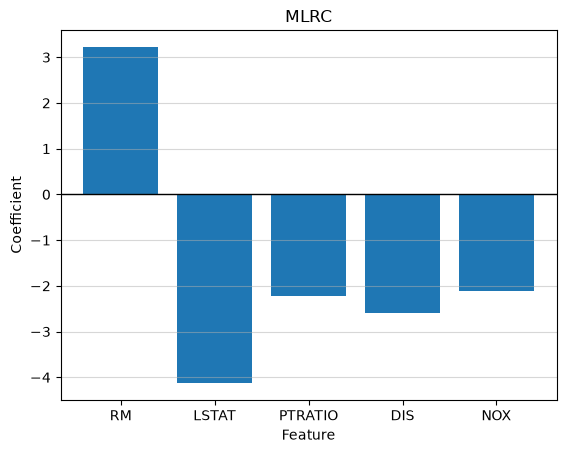

In [32]:
# TODO: coef_df를 이용해 feature별 회귀계수 막대그래프를 그리세요.
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': regressor.coef_
})

plt.bar(
    coef_df['feature'],
    coef_df['coef']
)

plt.axhline(
    y=0,
    color='black',
    linewidth=1
)

plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('MLRC')

plt.grid(axis='y', alpha=0.5)
plt.show()